# Load the Dataframe

In [ ]:
import pandas as pd  
# Run, data-cells in order. i.e. firstly run 1st cell then 
# run 2nd & hence-forth run it.

In [3]:
# First Station '.txt' file.
data_frame = pd.read_csv(r"data_small\TG_STAID000001.txt", skiprows=20, parse_dates=["    DATE"])  
#                       (↑) r => raw, used because '\T' is inbuilt used in Python. 
#                                 So, 'r' will tell Python that is Only string.
# parse_dates=["    DATE"] => Converts "    DATE" column into Python datetime object, which helps 
#                              to filer, sort, or manupilate dates easily later.

In [4]:
data_frame
# Actual Temperature = (TG)/10

,STAID,SOUID,DATE,TG,Q_TG
0,1,35381,1860-01-01,21,0
1,1,35381,1860-01-02,46,0
2,1,35381,1860-01-03,31,0
3,1,35381,1860-01-04,37,0
4,1,35381,1860-01-05,31,0
...,...,...,...,...,...
59316,1,35381,2022-05-27,-9999,9
59317,1,35381,2022-05-28,-9999,9
59318,1,35381,2022-05-29,-9999,9
59319,1,35381,2022-05-30,-9999,9


## Show certain rows

In [5]:
data_frame[10:20] # 10-19

,STAID,SOUID,DATE,TG,Q_TG
10,1,35381,1860-01-11,-5,0
11,1,35381,1860-01-12,-18,0
12,1,35381,1860-01-13,-27,0
13,1,35381,1860-01-14,-26,0
14,1,35381,1860-01-15,-37,0
15,1,35381,1860-01-16,-9,0
16,1,35381,1860-01-17,7,0
17,1,35381,1860-01-18,-6,0
18,1,35381,1860-01-19,-16,0
19,1,35381,1860-01-20,-19,0


## Show certain Columns

In [6]:
data_frame.columns

Index(['STAID', ' SOUID', '    DATE', '   TG', ' Q_TG'], dtype='object')

In [7]:
data_frame['   TG'] # Here, pandas produced series, by single '[]'.

0          21
1          46
2          31
3          37
4          31
         ... 
59316   -9999
59317   -9999
59318   -9999
59319   -9999
59320   -9999
Name:    TG, Length: 59321, dtype: int64

In [8]:
data_frame[['   TG', '    DATE']] 
# Here, pandas produced a Data-frame because we have Multiple-columns.
#        by multiple '[[]]'.

# Here, 'TG' in end is '-9999' => (Data isn't calculated that day.)

,TG,DATE
0,21,1860-01-01
1,46,1860-01-02
2,31,1860-01-03
3,37,1860-01-04
4,31,1860-01-05
...,...,...
59316,-9999,2022-05-27
59317,-9999,2022-05-28
59318,-9999,2022-05-29
59319,-9999,2022-05-30


# Simple Statistics and Filtering

In [9]:
data_frame.loc[data_frame['   TG'] != -9999]
# '.loc[]' => Used for condition, like if-else.
#  Here, when TG == -9999, then it will didn't give that row.

,STAID,SOUID,DATE,TG,Q_TG
0,1,35381,1860-01-01,21,0
1,1,35381,1860-01-02,46,0
2,1,35381,1860-01-03,31,0
3,1,35381,1860-01-04,37,0
4,1,35381,1860-01-05,31,0
...,...,...,...,...,...
53655,1,35381,2006-11-26,80,0
53656,1,35381,2006-11-27,70,0
53657,1,35381,2006-11-28,71,0
53658,1,35381,2006-11-29,63,0


In [10]:
data_frame.loc[data_frame['   TG'] != -9999]['   TG'].mean() / 10
# data_frame[]['   TG'] => only gives ['   TG'] column from the Table.
#  '.mean()' => Gives average.

np.float64(6.360787526128467)

In [11]:
data_frame.loc[data_frame['   TG'] != -9999]['   TG'].max() / 10

np.float64(26.2)

In [13]:
data_frame.loc[data_frame['   TG'] != -9999]['   TG'].min() / 10

np.float64(-28.8)

<Axes: >

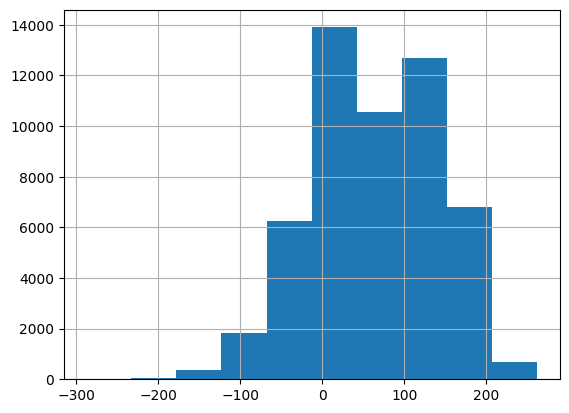

In [14]:
data_frame.loc[data_frame['   TG'] != -9999]['   TG'].hist() 
# data_frame.loc[data_frame['   TG'] != -9999]['   TG'].hist() / 10  # Error.
# '.hist()' => Histogram, used to represent data in Graphs.

# Get certain cells

In [13]:
data_frame

,STAID,SOUID,DATE,TG,Q_TG
0,1,35381,1860-01-01,21,0
1,1,35381,1860-01-02,46,0
2,1,35381,1860-01-03,31,0
3,1,35381,1860-01-04,37,0
4,1,35381,1860-01-05,31,0
...,...,...,...,...,...
59316,1,35381,2022-05-27,-9999,9
59317,1,35381,2022-05-28,-9999,9
59318,1,35381,2022-05-29,-9999,9
59319,1,35381,2022-05-30,-9999,9


In [16]:
data_frame.loc[data_frame['    DATE'] == "1860-01-05"]

,STAID,SOUID,DATE,TG,Q_TG
4,1,35381,1860-01-05,31,0


In [17]:
type(data_frame.loc[data_frame['    DATE'] == "1860-01-05"]) # => DataFrame

pandas.core.frame.DataFrame

In [16]:
data_frame.loc[data_frame['    DATE'] == "1860-01-05"]['   TG'] 
# => Only gives '   TG' Column.

4    31
Name:    TG, dtype: int64

In [18]:
data_frame.loc[data_frame['    DATE'] == "1860-01-05"]['   TG'].squeeze() / 10
# '.squeeze()' => Gives value in ['   TG'] Column.

np.float64(3.1)

In [19]:
data_frame.loc[data_frame['   TG'] == data_frame['   TG'].max()]
# Gives 'max.' Temperature row.

,STAID,SOUID,DATE,TG,Q_TG
3150,1,35381,1868-08-16,262,0


In [20]:
data_frame.loc[data_frame['   TG'] == data_frame['   TG'].max()]['    DATE'].squeeze()
# Gives 'max.' Temperature row.

Timestamp('1868-08-16 00:00:00')

In [21]:
data_frame.loc[3, '   TG'] 
# Gives 'TG' of row with no. = 3. 
# (which is 4th row, because indexing starts from '0'.) 

np.int64(37)

# Calculate a new Column out of existing Column

In [22]:
import numpy as np
data_frame["TG0"] = data_frame['   TG'].mask(data_frame['   TG'] == -9999, np.nan)
# '.mask()' => without, i.e. it didn't take '-9999' ['   TG'] values   (↑)
# '.nan' => Symbolises none values. ('NaN' => none)

data_frame

,STAID,SOUID,DATE,TG,Q_TG,TG0
0,1,35381,1860-01-01,21,0,21.0
1,1,35381,1860-01-02,46,0,46.0
2,1,35381,1860-01-03,31,0,31.0
3,1,35381,1860-01-04,37,0,37.0
4,1,35381,1860-01-05,31,0,31.0
...,...,...,...,...,...,...
59316,1,35381,2022-05-27,-9999,9,NaN
59317,1,35381,2022-05-28,-9999,9,NaN
59318,1,35381,2022-05-29,-9999,9,NaN
59319,1,35381,2022-05-30,-9999,9,NaN


In [23]:
data_frame["TG"] = data_frame['TG0'] / 10
# ["TG"] => New column we made & ("TG" != "   TG")
#                                         (↑)Spaces

In [24]:
data_frame

,STAID,SOUID,DATE,TG,Q_TG,TG0,TG
0,1,35381,1860-01-01,21,0,21.0,2.1
1,1,35381,1860-01-02,46,0,46.0,4.6
2,1,35381,1860-01-03,31,0,31.0,3.1
3,1,35381,1860-01-04,37,0,37.0,3.7
4,1,35381,1860-01-05,31,0,31.0,3.1
...,...,...,...,...,...,...,...
59316,1,35381,2022-05-27,-9999,9,NaN,NaN
59317,1,35381,2022-05-28,-9999,9,NaN,NaN
59318,1,35381,2022-05-29,-9999,9,NaN,NaN
59319,1,35381,2022-05-30,-9999,9,NaN,NaN


# Plotting

<Axes: >

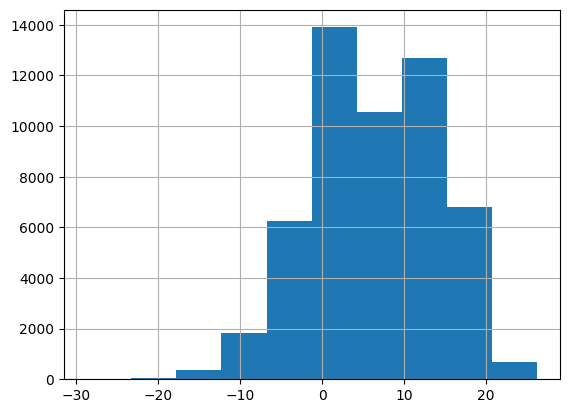

In [25]:
data_frame["TG"].hist()

<Axes: xlabel='    DATE', ylabel='TG'>

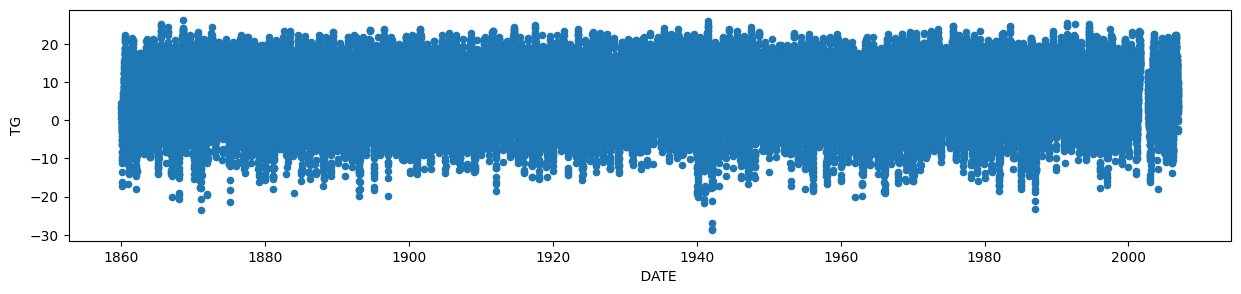

In [26]:
# data_frame.plot(x='    DATE', y="TG", figsize=(15, 3))   # UR
data_frame.plot(x='    DATE', y="TG", figsize=(15, 3), kind="scatter") # (CR => Comment & Run.)
# '.plot()' => Plots graph in x-y coordinate,
#       (↑) with x => 'DATE', y="TG", with figure_size=(15,3)
#                                                       (↑)(x,y)

<Axes: xlabel='    DATE'>

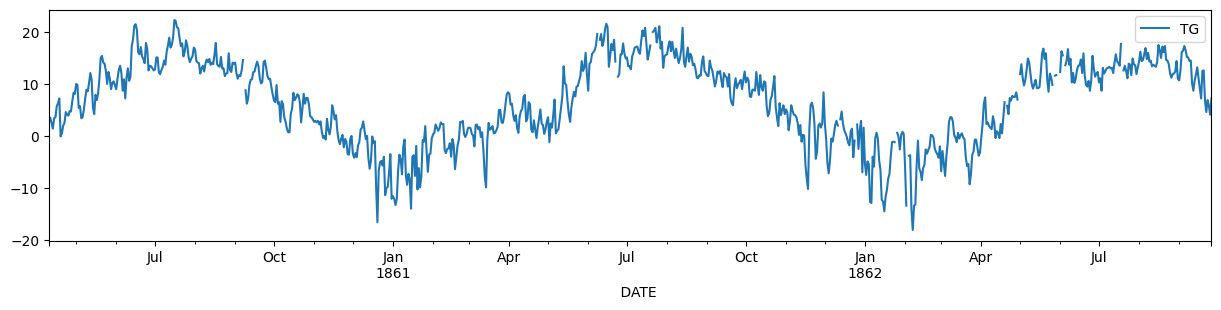

In [27]:
data_frame[100:1000].plot(x='    DATE', y="TG", figsize=(15, 3))